In [8]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

data = r"C:\Users\Noman khan\Downloads\archive (7)\train.csv"
df = pd.read_csv(data)
print(df.head())
print(df.info())
print(df.describe())
print(df.columns)

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

print(df.isnull().sum())

print(df.select_dtypes(include=object).columns.tolist())
print(df.select_dtypes(include=float).columns.tolist())
print(df.select_dtypes(include=int).columns.tolist())
 

## Data Story
I download titanic dataset from kaggle, and load it by using pd.read_csv method. I discovered in the dataset that it has 891 rows, 12 columns. Out of 12 columns 5 is a object, 5 is a int type columns and 2 is a float columns. By using df.isnull().sum(), i discovered that cabin column has 687 missing values, age has 177 missing values and Ebarked has only 2 missing values . I also apply describe() method which gives the statistical summary.


In [9]:
print(df["Embarked"].head())

df["Age"] = df['Age'].fillna(df["Age"].mean())
df["Embarked"] = df['Embarked'].fillna(df["Embarked"].mode()[0])
df = df.drop('Cabin', axis=1, errors="ignore")

print(df.columns)
print(df["Embarked"].isnull().sum())

0    S
1    C
2    S
3    S
4    S
Name: Embarked, dtype: object
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')
0


## Why i used Fillna() and drop?
I used fillna() on 'Age' and "Embarked" which had 177 and 2 missing values respectively. Beacuase age column is a int column which has only  177 missnig values so droping this column would be wrong so i filled it by mean() methd and Embarked has only 2 and it is a object column so i filled it by mode method. Object is column is filled with most repeated value that is why i used mode. And Cabin column has dropped because it has many missing values. So droping it is not bad choice.                    

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(x=df["Age"], color="skyblue")
plt.title("Boxplot on Age column to detect outliars.")
plt.xlabel("Age")
plt.show()

In [ ]:
sns.histplot(df["Fare"], color="purple")
plt.title("Distribution of Fare")
plt.show()


In [ ]:
sns.countplot(x="Survived", data=df)
plt.title("Passenger Survival Count")
plt.ylabel("No. of Passengers")  
plt.show()

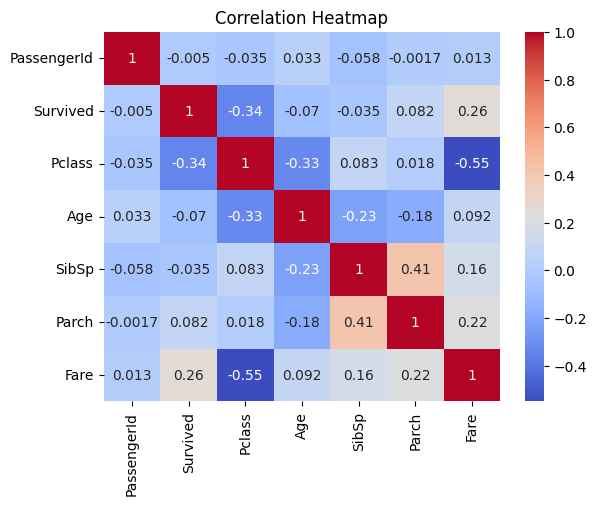

In [3]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Finding
Based on the heatmap, Pclass has the strongest relationship with Survival(-0.34). This means passeners in higher classes(1st class) were more likely to survive than those in lower classes. 

In [26]:
print(df.select_dtypes(include=object).columns)
df_cleaned = df.drop(columns=["Name", "Ticket"], errors='ignore')
df_encoded = pd.get_dummies(df_cleaned, columns=["Sex", "Embarked"], drop_first=True)


X = df_encoded.drop(columns=['Survived'])
y = df_encoded['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

Index(['Name', 'Sex', 'Ticket', 'Embarked'], dtype='object')


In [31]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Success! Model trained and predictions made without errors.")

Success! Model trained and predictions made without errors.


In [33]:
print("Accuracy_score", accuracy_score(y_test, y_pred))
print("Confusion Matrix", confusion_matrix(y_test, y_pred))


Accuracy_score 0.8044692737430168
Confusion Matrix [[89 16]
 [19 55]]


## Confusion Matrix Explanation
The confusion matrix is telling the story of the model that true negative number is 89. TN mean model correctly predict that 89 passegers did not survive. False positive are 19 which mean model predict passengers survived but they did not survived. False negative are 16 which mean model says they did not survived but actually they survived. True negative are 55 which mean model correctly predict that 55 did  survived.   